# Import libraries

In [77]:
!pip install transformers torch scikit-learn matplotlib seaborn wordcloud -q

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import os

from collections import Counter
from tabulate import tabulate


from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

print('All libraries imported successfully!')

All libraries imported successfully!


# Import Dataset

In [2]:
from google.colab import files
uploaded = files.upload()  # Select train.csv from your computer

Saving train.csv to train.csv


# Read The Dataset

In [3]:
df = pd.read_csv('train.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset Shape: (159571, 8)
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


# Checking the missing values

In [4]:
print('=== Dataset Shape ===')
print(df.shape)
print('\n=== Missing Values per Column ===')
print(df.isnull().sum())

=== Dataset Shape ===
(159571, 8)

=== Missing Values per Column ===
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


# Handle missing values

In [5]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Drop rows with missing comment text
df = df.dropna(subset=['comment_text'])

# Fill missing label values with 0
df[label_cols] = df[label_cols].fillna(0)

print(f'Dataset shape after handling missing values: {df.shape}')
print('\nMissing values remaining:')
print(df.isnull().sum())

Dataset shape after handling missing values: (159571, 8)

Missing values remaining:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


# cleaning the texts

In [23]:
def clean_text(text):
    text = str(text).lower()                         # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)       # Remove URLs
    text = re.sub(r'\n', ' ', text)                  # Remove newlines
    text = re.sub(r'\s+', ' ', text).strip()         # Remove extra spaces
    return text

df['clean_text'] = df['comment_text'].apply(clean_text)

print('Text cleaning done!')
print('\nBefore cleaning:')
print(df['comment_text'].iloc[6][:200])
print('\nAfter cleaning:')
print(df['clean_text'].iloc[6][:200])

Text cleaning done!

Before cleaning:
COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK

After cleaning:
cocksucker before you piss around on my work


# label columns

In [7]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

texts  = df['clean_text'].tolist()
labels = df[label_cols].values.astype(float)

print(f'Total samples:  {len(texts)}')
print(f'Labels shape:   {labels.shape}')
print(f'Label columns:  {label_cols}')
print(f'\nSample label row: {labels[6]}  → {dict(zip(label_cols, labels[6].astype(int)))}')

Total samples:  159571
Labels shape:   (159571, 6)
Label columns:  ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Sample label row: [1. 1. 1. 0. 1. 0.]  → {'toxic': np.int64(1), 'severe_toxic': np.int64(1), 'obscene': np.int64(1), 'threat': np.int64(0), 'insult': np.int64(1), 'identity_hate': np.int64(0)}


# Adding helper columns

In [8]:
df['any_toxic']       = df[label_cols].max(axis=1)
df['comment_length']  = df['clean_text'].apply(lambda x: len(str(x).split()))

print(f'Toxic comments:     {df["any_toxic"].sum()} ({df["any_toxic"].mean()*100:.1f}%)')
print(f'Clean comments:     {(df["any_toxic"]==0).sum()} ({(df["any_toxic"]==0).mean()*100:.1f}%)')
print(f'Avg comment length: {df["comment_length"].mean():.1f} words')

Toxic comments:     16225 (10.2%)
Clean comments:     143346 (89.8%)
Avg comment length: 67.2 words


# Descriptive columns

In [25]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

summary = pd.DataFrame({
    'Total Positive': df[label_cols].sum(),
    'Mean (%)':       (df[label_cols].mean() * 100).round(2),
    'Std Dev':        df[label_cols].std().round(4),
    'Min':            df[label_cols].min(),
    'Max':            df[label_cols].max(),
})

print('=== Descriptive Summary: All 6 Labels ===')
print(summary.to_string())
print(f'\nTotal comments in dataset: {len(df):,}')
print(f'Comments with ANY toxic label: {int(df["any_toxic"].sum()):,} ({df["any_toxic"].mean()*100:.2f}%)')
print(f'Completely clean comments:     {int((df["any_toxic"]==0).sum()):,} ({(df["any_toxic"]==0).mean()*100:.2f}%)')

=== Descriptive Summary: All 6 Labels ===
               Total Positive  Mean (%)  Std Dev  Min  Max
toxic                   15294      9.58   0.2944    0    1
severe_toxic             1595      1.00   0.0995    0    1
obscene                  8449      5.29   0.2239    0    1
threat                    478      0.30   0.0546    0    1
insult                   7877      4.94   0.2166    0    1
identity_hate            1405      0.88   0.0934    0    1

Total comments in dataset: 159,571
Comments with ANY toxic label: 16,225 (10.17%)
Completely clean comments:     143,346 (89.83%)


# Class Distribution of all labels

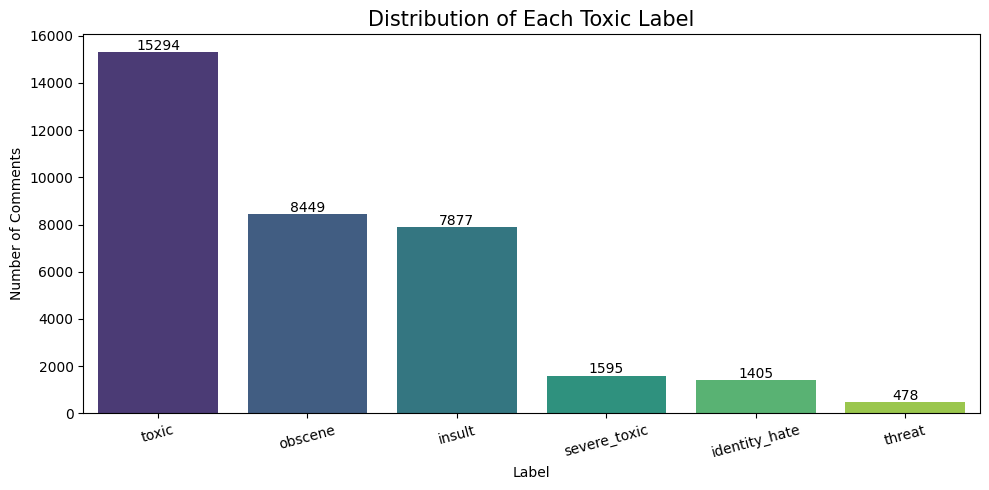

Percentage of each label in dataset:
toxic            9.58%
obscene          5.29%
insult           4.94%
severe_toxic      1.0%
identity_hate    0.88%
threat            0.3%
dtype: object


In [9]:
label_counts = df[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Each Toxic Label', fontsize=15)
plt.xlabel('Label')
plt.ylabel('Number of Comments')
plt.xticks(rotation=15)
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 100, str(int(v)), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print('Percentage of each label in dataset:')
print((label_counts / len(df) * 100).round(2).astype(str) + '%')

# Toxic vs clean comments

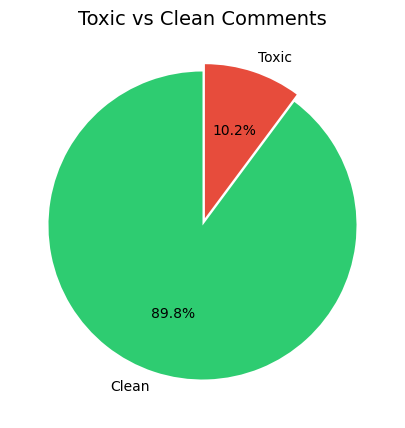

Clean comments: 143,346
Toxic comments: 16,225


In [10]:
counts = df['any_toxic'].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(counts.values,
        labels=['Clean', 'Toxic'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        startangle=90,
        explode=(0, 0.05))
plt.title('Toxic vs Clean Comments', fontsize=14)
plt.show()

print(f'Clean comments: {counts[0]:,}')
print(f'Toxic comments: {counts[1]:,}')

# Comment length distribution

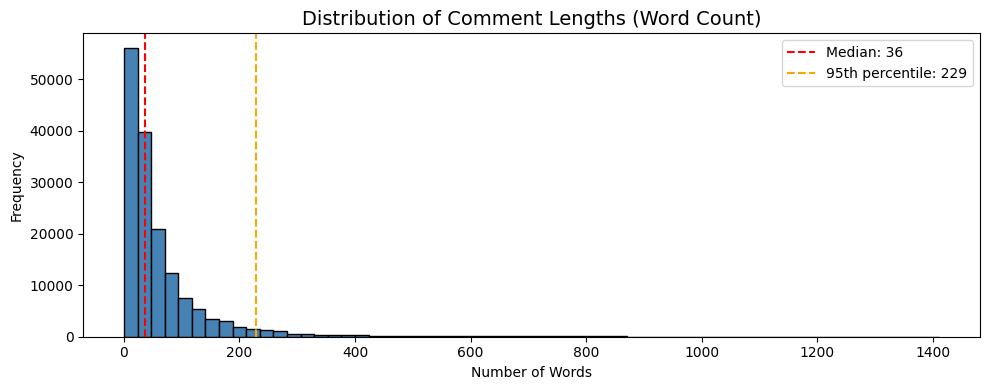

Mean:            67.2 words
Median:          36.0 words
Max:             1411 words
95th percentile: 229 words  ← used as max_length


In [11]:
plt.figure(figsize=(10, 4))
plt.hist(df['comment_length'], bins=60, color='steelblue', edgecolor='black')
plt.title('Distribution of Comment Lengths (Word Count)', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['comment_length'].median(), color='red',    linestyle='--', label=f"Median: {df['comment_length'].median():.0f}")
plt.axvline(df['comment_length'].quantile(0.95), color='orange', linestyle='--', label=f"95th percentile: {df['comment_length'].quantile(0.95):.0f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f'Mean:            {df["comment_length"].mean():.1f} words')
print(f'Median:          {df["comment_length"].median():.1f} words')
print(f'Max:             {df["comment_length"].max()} words')
print(f'95th percentile: {df["comment_length"].quantile(0.95):.0f} words  ← used as max_length')

# HeatMap Co_occurence

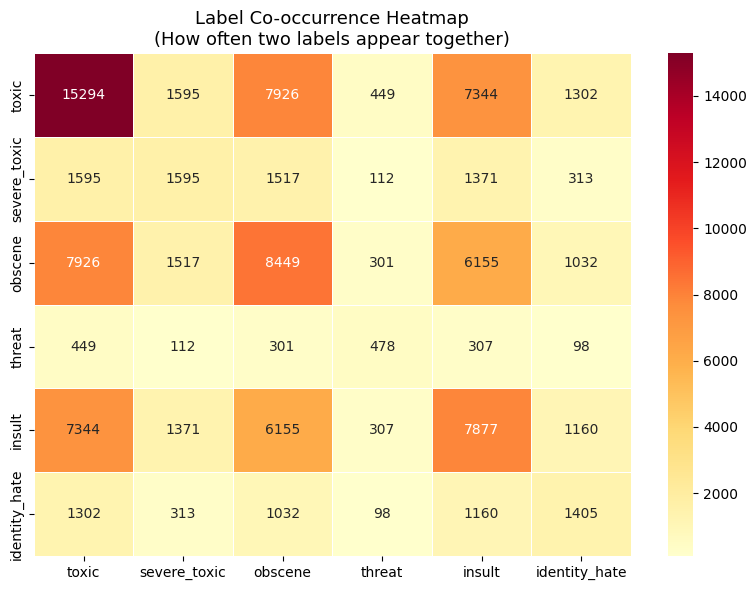

In [12]:
co_occurrence = df[label_cols].T.dot(df[label_cols])

plt.figure(figsize=(8, 6))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5)
plt.title('Label Co-occurrence Heatmap\n(How often two labels appear together)', fontsize=13)
plt.tight_layout()
plt.show()

# WordCloud of Toxic Comments

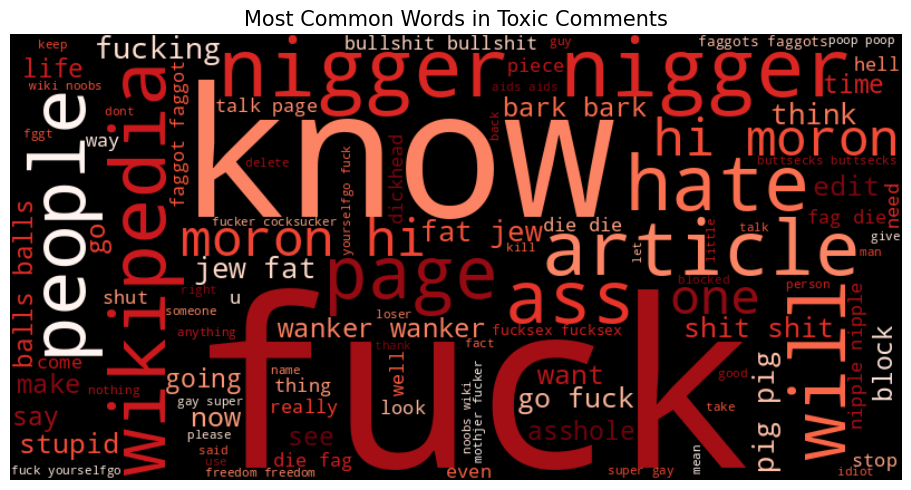

In [24]:
toxic_text = ' '.join(df[df['toxic'] == 1]['clean_text'].values)

wordcloud = WordCloud(width=800, height=400, background_color='black',
                      colormap='Reds', max_words=100).generate(toxic_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Toxic Comments', fontsize=15)
plt.tight_layout()
plt.show()

# Wordcloud of Clean Comment

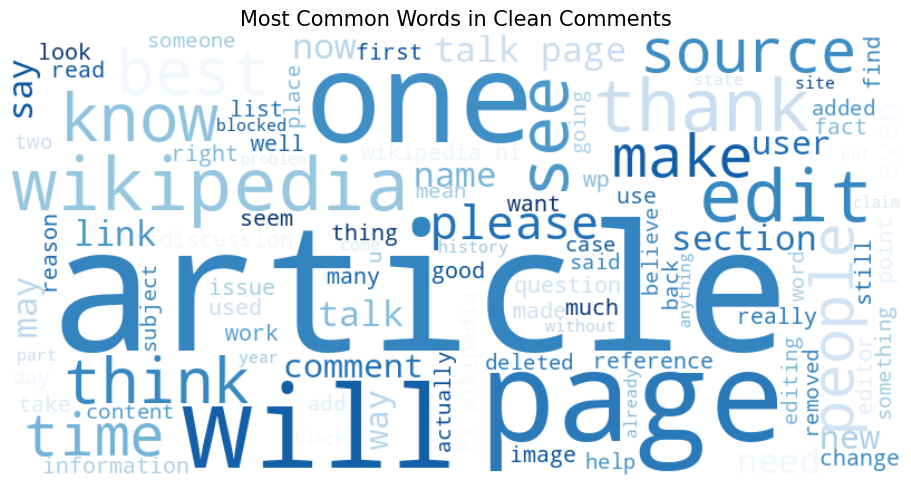

In [14]:
clean_text_sample = ' '.join(df[df['any_toxic'] == 0]['clean_text'].sample(5000, random_state=42).values)

wordcloud_clean = WordCloud(width=800, height=400, background_color='white',
                             colormap='Blues', max_words=100).generate(clean_text_sample)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud_clean, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Clean Comments', fontsize=15)
plt.tight_layout()
plt.show()

# Train and test Split

In [26]:
texts  = df['clean_text'].tolist()
labels = df[label_cols].values.astype(float)

X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print(f'Training samples:   {len(X_train):,}')
print(f'Validation samples: {len(X_val):,}')
print(f'Test samples:       {len(X_test):,}')

Training samples:   127,656
Validation samples: 15,957
Test samples:       15,958


# Build Vocabulary from Training Data

In [30]:
MAX_VOCAB = 30000
MAX_LEN   = 150
EMBED_DIM = 100

all_words = [word for text in X_train for word in text.split()]
vocab     = ['<PAD>', '<UNK>'] + [w for w, _ in Counter(all_words).most_common(MAX_VOCAB)]
word2idx  = {w: i for i, w in enumerate(vocab)}

print(f'Vocabulary size: {len(vocab):,}')

Vocabulary size: 30,002


# Text Dataset and DataLoaders

In [31]:
def text_to_ids(text, word2idx, max_len):
    tokens = text.split()[:max_len]
    ids    = [word2idx.get(w, 1) for w in tokens]  # 1 = <UNK>
    ids    = ids + [0] * (max_len - len(ids))       # 0 = <PAD>
    return ids

class TextDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.ids    = [text_to_ids(t, word2idx, max_len) for t in texts]
        self.labels = labels

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        return {
            'ids':    torch.tensor(self.ids[idx],    dtype=torch.long),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

BATCH_SIZE = 64

train_loader_rnn = DataLoader(TextDataset(X_train, y_train, word2idx, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader_rnn   = DataLoader(TextDataset(X_val,   y_val,   word2idx, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)
test_loader_rnn  = DataLoader(TextDataset(X_test,  y_test,  word2idx, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader_rnn)}')
print(f'Val batches:   {len(val_loader_rnn)}')
print(f'Test batches:  {len(test_loader_rnn)}')

Train batches: 1995
Val batches:   250
Test batches:  250


# Compute Class Weights for Imbalance

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

pos_counts  = df[label_cols].sum().values
neg_counts  = len(df) - pos_counts
pos_weights = torch.tensor(neg_counts / pos_counts, dtype=torch.float).to(device)

print(f'Class weights: {pos_weights.cpu().numpy().round(2)}')

Device: cpu
Class weights: [  9.43  99.04  17.89 332.83  19.26 112.57]


# Training and Evaluation Functions

In [33]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    for batch in loader:
        ids  = batch['ids'].to(device)
        lbls = batch['labels'].to(device)
        optimizer.zero_grad()
        out  = model(ids)
        loss = loss_fn(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_one_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_lbls = 0, [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['ids'].to(device)
            lbls = batch['labels'].to(device)
            out  = model(ids)
            loss = loss_fn(out, lbls)
            total_loss += loss.item()
            all_preds.append(torch.sigmoid(out).cpu().numpy())
            all_lbls.append(lbls.cpu().numpy())
    all_preds = np.vstack(all_preds) > 0.5
    all_lbls  = np.vstack(all_lbls)
    f1 = f1_score(all_lbls, all_preds, average='macro', zero_division=0)
    return total_loss / len(loader), f1

print('Train and eval functions ready!')

Train and eval functions ready!


# Deep Learning Model

# 1. TextCNN Model

1.1  TextCNN  Baseline Architecture

In [34]:
class TextCNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim,
                 num_filters=128, filter_sizes=(2, 3, 4), num_labels=6):
        super(TextCNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs     = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.dropout   = nn.Dropout(0.4)
        self.fc        = nn.Linear(num_filters * len(filter_sizes), num_labels)

    def forward(self, ids):
        embedded = self.embedding(ids).permute(0, 2, 1)   # (B, E, L)
        pooled   = []
        for conv in self.convs:
            x = torch.relu(conv(embedded))                # (B, F, L-fs+1)
            x = x.max(dim=2).values                       # Max pooling
            pooled.append(x)
        cat = torch.cat(pooled, dim=1)                    # (B, F*3)
        return self.fc(self.dropout(cat))

cnn_model = TextCNNModel(len(vocab), EMBED_DIM).to(device)
print(f'TextCNN Total parameters: {sum(p.numel() for p in cnn_model.parameters()):,}')

TextCNN Total parameters: 3,118,094


1.2 Train TextCNN Model

In [35]:
EPOCHS        = 3
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
loss_fn_cnn   = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

cnn_train_losses, cnn_val_losses, cnn_val_f1s = [], [], []

print('Training TextCNN...')
for epoch in range(EPOCHS):
    tl     = train_one_epoch(cnn_model, train_loader_rnn, optimizer_cnn, loss_fn_cnn, device)
    vl, vf = eval_one_epoch(cnn_model,  val_loader_rnn,   loss_fn_cnn,   device)
    cnn_train_losses.append(tl)
    cnn_val_losses.append(vl)
    cnn_val_f1s.append(vf)
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | Val F1: {vf:.4f}')

print(f'\nTextCNN Best Val F1: {max(cnn_val_f1s):.4f}')

Training TextCNN...
Epoch 1/3 | Train Loss: 0.7808 | Val Loss: 0.5212 | Val F1: 0.3006
Epoch 2/3 | Train Loss: 0.4757 | Val Loss: 0.4700 | Val F1: 0.3954
Epoch 3/3 | Train Loss: 0.3877 | Val Loss: 0.5072 | Val F1: 0.4495

TextCNN Best Val F1: 0.4495


1.3 Basline Accuracy

In [78]:
cnn_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader_rnn:

        ids = batch['ids'].to(device)
        labels_batch = batch['labels'].to(device)

        outputs = cnn_model(ids)

        probs = torch.sigmoid(outputs).cpu().numpy()

        all_preds.append(probs)
        all_labels.append(labels_batch.cpu().numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

binary_preds = (all_preds > 0.5).astype(int)

cnn_baseline_accuracy = accuracy_score(all_labels, binary_preds)

print("CNN Baseline Accuracy:", round(cnn_baseline_accuracy,4))

CNN Baseline Accuracy: 0.8731


1.4 TextCNN Variant Architecture

In [55]:
class TextCNNModel_v2(nn.Module):
    def __init__(self, vocab_size, embed_dim,
                 num_filters=256, filter_sizes=(3,4,5), num_labels=6):
        super(TextCNNModel_v2, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs)
            for fs in filter_sizes
        ])

        self.dropout = nn.Dropout(0.5)   # increased dropout
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_labels)

    def forward(self, ids):

        embedded = self.embedding(ids).permute(0,2,1)

        pooled = []

        for conv in self.convs:
            x = torch.relu(conv(embedded))
            x = x.max(dim=2).values
            pooled.append(x)

        cat = torch.cat(pooled, dim=1)

        return self.fc(self.dropout(cat))


cnn_model_v2 = TextCNNModel_v2(len(vocab), EMBED_DIM).to(device)

print(f"CNN Variant parameters: {sum(p.numel() for p in cnn_model_v2.parameters()):,}")

CNN Variant parameters: 3,312,782


1.5 Subset Dataset

In [53]:
subset_size = 5000   # small subset for faster hyperparameter experiment

df_subset = df.sample(n=subset_size, random_state=42)

print("Original dataset size:", len(df))
print("Subset dataset size:", len(df_subset))

Original dataset size: 159571
Subset dataset size: 5000


1.6 Subset Label

In [57]:
# Prepare subset texts and labels

texts_subset  = df_subset['clean_text'].tolist()
labels_subset = df_subset[label_cols].values.astype(float)

# Use the SAME TextDataset used earlier
train_dataset_variant = TextDataset(
    texts_subset,
    labels_subset,
    word2idx,
    MAX_LEN
)

train_loader_variant = DataLoader(
    train_dataset_variant,
    batch_size=32,
    shuffle=True
)

print("Subset training loader ready!")

Subset training loader ready!


1.7 HyperParameter Tuning

In [58]:
optimizer_cnn_v2 = torch.optim.Adam(cnn_model_v2.parameters(), lr=5e-4)

loss_fn_cnn_v2 = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

cnn2_train_losses = []
cnn2_val_losses = []
cnn2_val_f1s = []

print("Training CNN Variant...")

for epoch in range(EPOCHS):

    tl = train_one_epoch(
        cnn_model_v2,
        train_loader_variant,   # uses reduced dataset
        optimizer_cnn_v2,
        loss_fn_cnn_v2,
        device
    )

    vl, vf = eval_one_epoch(
        cnn_model_v2,
        val_loader_rnn,   # validation remains full dataset
        loss_fn_cnn_v2,
        device
    )

    cnn2_train_losses.append(tl)
    cnn2_val_losses.append(vl)
    cnn2_val_f1s.append(vf)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | Val F1: {vf:.4f}")

print(f"\nCNN Variant Best Val F1: {max(cnn2_val_f1s):.4f}")

Training CNN Variant...
Epoch 1/3 | Train Loss: 1.3976 | Val Loss: 1.2225 | Val F1: 0.1273
Epoch 2/3 | Train Loss: 0.8771 | Val Loss: 1.1351 | Val F1: 0.1662
Epoch 3/3 | Train Loss: 0.6937 | Val Loss: 1.2074 | Val F1: 0.2720

CNN Variant Best Val F1: 0.2720


1.8 Evaluation

In [70]:
cnn_model_v2.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader_rnn:

        ids = batch['ids'].to(device)
        labels_batch = batch['labels'].to(device)

        outputs = cnn_model_v2(ids)

        probs = torch.sigmoid(outputs).cpu().numpy()

        all_preds.append(probs)
        all_labels.append(labels_batch.cpu().numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

binary_preds = (all_preds > 0.5).astype(int)

cnn_variant_accuracy = accuracy_score(all_labels, binary_preds)

print("CNN Variant Accuracy:", round(cnn_variant_accuracy,4))

CNN Variant Accuracy: 0.8043


1.9 Compare Both TextCNN Architecture

In [71]:
comparison = pd.DataFrame({
    "Model": [
        "CNN Baseline",
        "CNN Variant"
    ],
    "Best Validation F1": [
        max(cnn_val_f1s),
        max(cnn2_val_f1s)
    ],
    "Subset Accuracy":[
        cnn_baseline_accuracy,
        cnn_variant_accuracy
    ]
})

print(tabulate(comparison, headers='keys', tablefmt='grid', showindex=False))

+--------------+----------------------+-------------------+
| Model        |   Best Validation F1 |   Subset Accuracy |
+==============+======================+===================+
| CNN Baseline |             0.449502 |          0.873104 |
+--------------+----------------------+-------------------+
| CNN Variant  |             0.272007 |          0.804299 |
+--------------+----------------------+-------------------+


1.10 Training Curves

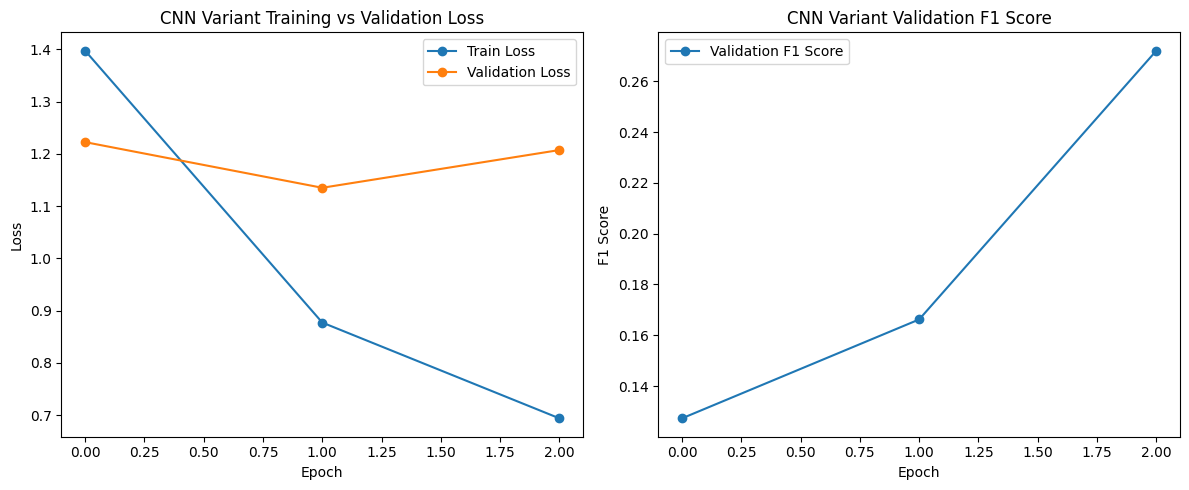

In [60]:
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(cnn2_train_losses, label='Train Loss', marker='o')
plt.plot(cnn2_val_losses, label='Validation Loss', marker='o')
plt.title('CNN Variant Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# F1 plot
plt.subplot(1,2,2)
plt.plot(cnn2_val_f1s, label='Validation F1 Score', marker='o')
plt.title('CNN Variant Validation F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()